In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [ ]:
import zipfile
import os

zip_file = "archive (1).zip"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("retail_dataset")

print("Dataset extracted successfully!")
print(os.listdir("retail_dataset"))

Dataset extracted successfully!
['retail_sales_dataset.csv']


In [ ]:
import pandas as pd
import glob
import os

# Find CSV file inside extracted folder
csv_files = glob.glob("retail_dataset/**/*.csv", recursive=True)

print("CSV files found:", csv_files)

# Load the CSV file
df = pd.read_csv(csv_files[0])

print("\nDataset loaded successfully!")
print("Rows and Columns:", df.shape)

df.head()

CSV files found: ['retail_dataset/retail_sales_dataset.csv']

Dataset loaded successfully!
Rows and Columns: (1000, 9)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [ ]:
print("----- DATASET INFORMATION -----")
df.info()

print("\n----- MISSING VALUES -----")
print(df.isnull().sum())

print("\n----- DUPLICATE ROWS -----")
print(df.duplicated().sum())

print("\n----- STATISTICAL SUMMARY -----")
display(df.describe(include="all"))

----- DATASET INFORMATION -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB

----- MISSING VALUES -----
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

----- DUPLICATE ROWS -----
0

----- STATISTICAL SUMMARY -----


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000,1000,1000.00000,1000,1000.000000,1000.000000,1000.000000
unique,NaN,345,1000,2,NaN,3,NaN,NaN,NaN
top,NaN,2023-05-16,CUST1000,Female,NaN,Clothing,NaN,NaN,NaN
freq,NaN,11,1,510,NaN,351,NaN,NaN,NaN
mean,500.500000,NaN,NaN,NaN,41.39200,NaN,2.514000,179.890000,456.000000
std,288.819436,NaN,NaN,NaN,13.68143,NaN,1.132734,189.681356,559.997632
min,1.000000,NaN,NaN,NaN,18.00000,NaN,1.000000,25.000000,25.000000
25%,250.750000,NaN,NaN,NaN,29.00000,NaN,1.000000,30.000000,60.000000
50%,500.500000,NaN,NaN,NaN,42.00000,NaN,3.000000,50.000000,135.000000
75%,750.250000,NaN,NaN,NaN,53.00000,NaN,4.000000,300.000000,900.000000


In [ ]:
# Convert Date column to datetime format

df["Date"] = pd.to_datetime(df["Date"])

print("Date conversion completed!")

print("\n----- UPDATED DATA TYPES -----")
print(df.dtypes)

print("\n----- DATE RANGE -----")
print("Start Date:", df["Date"].min())
print("End Date:", df["Date"].max())

Date conversion completed!

----- UPDATED DATA TYPES -----
Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

----- DATE RANGE -----
Start Date: 2023-01-01 00:00:00
End Date: 2024-01-01 00:00:00


In [ ]:
# Sales analysis by product category

category_sales = df.groupby("Product Category")["Total Amount"].sum().sort_values(
    ascending=False
)

print("----- TOTAL SALES BY CATEGORY -----")
print(category_sales)

----- TOTAL SALES BY CATEGORY -----
Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


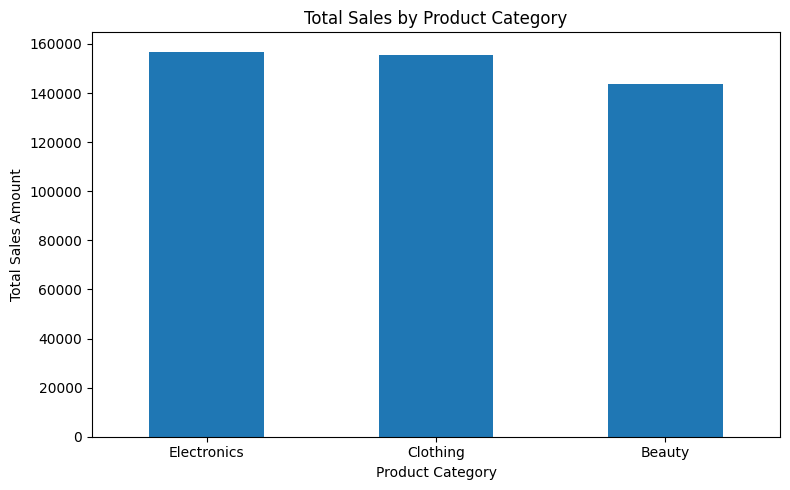

In [ ]:
import matplotlib.pyplot as plt

# Bar chart for category-wise sales

plt.figure(figsize=(8, 5))

category_sales.plot(kind="bar")

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Total sales by gender

gender_sales = df.groupby("Gender")["Total Amount"].sum()

print("----- TOTAL SALES BY GENDER -----")
print(gender_sales)

----- TOTAL SALES BY GENDER -----
Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64


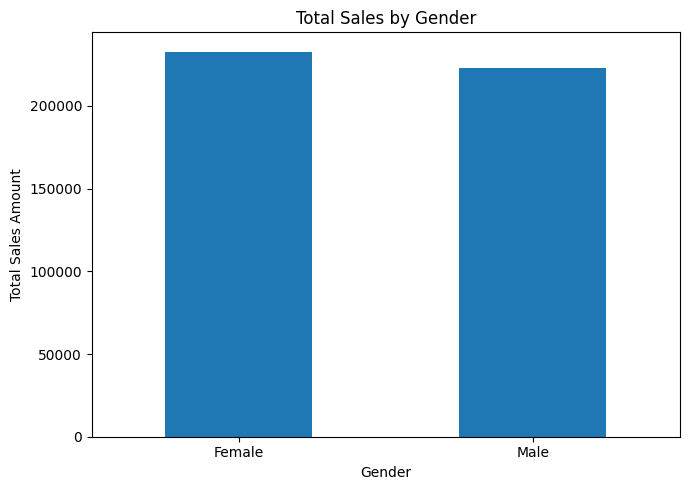

In [ ]:
# Bar chart for gender-wise sales

plt.figure(figsize=(7, 5))

gender_sales.plot(kind="bar")

plt.title("Total Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Create age groups

df["Age Group"] = pd.cut(
    df["Age"],
    bins=[17, 25, 35, 45, 55, 65],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65"]
)

# Calculate sales by age group

age_group_sales = df.groupby(
    "Age Group", observed=False
)["Total Amount"].sum()

print("----- TOTAL SALES BY AGE GROUP -----")
print(age_group_sales)

----- TOTAL SALES BY AGE GROUP -----
Age Group
18-25     84550
26-35     98480
36-45     91870
46-55    100690
56-65     80410
Name: Total Amount, dtype: int64


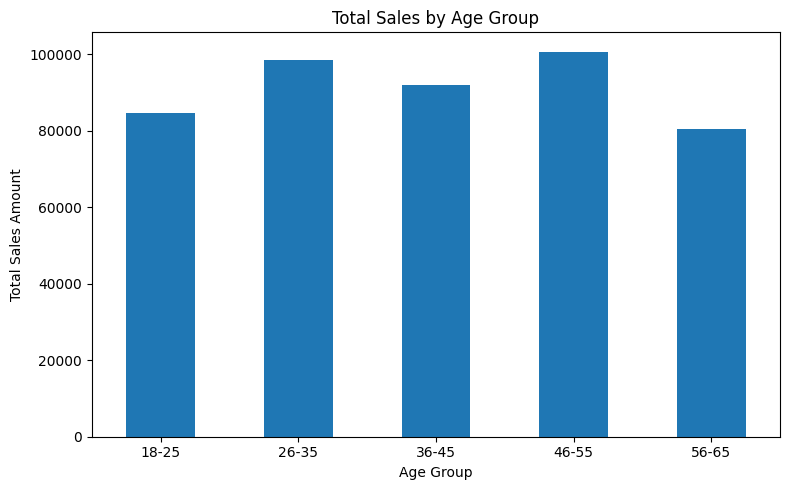

In [ ]:
# Bar chart for age group sales

plt.figure(figsize=(8, 5))

age_group_sales.plot(kind="bar")

plt.title("Total Sales by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Create Month column

df["Month"] = df["Date"].dt.to_period("M")

# Calculate monthly sales

monthly_sales = df.groupby("Month")["Total Amount"].sum()

print("----- MONTHLY SALES -----")
print(monthly_sales)

----- MONTHLY SALES -----
Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64


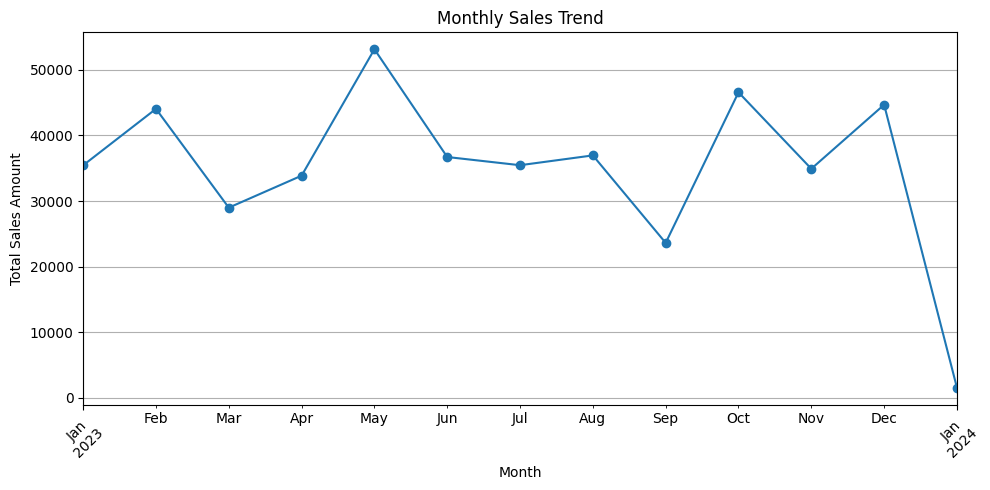

In [ ]:
# Monthly sales line chart

plt.figure(figsize=(10, 5))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales Amount")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

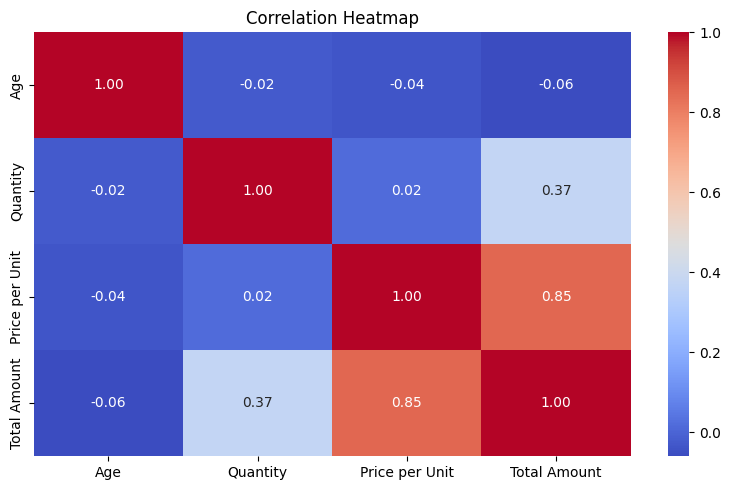

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
numeric_columns = [
    "Age",
    "Quantity",
    "Price per Unit",
    "Total Amount"
]

# Create correlation matrix
correlation_matrix = df[numeric_columns].corr()

# Create heatmap
plt.figure(figsize=(8, 5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

----- TRANSACTIONS BY CATEGORY -----
Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64


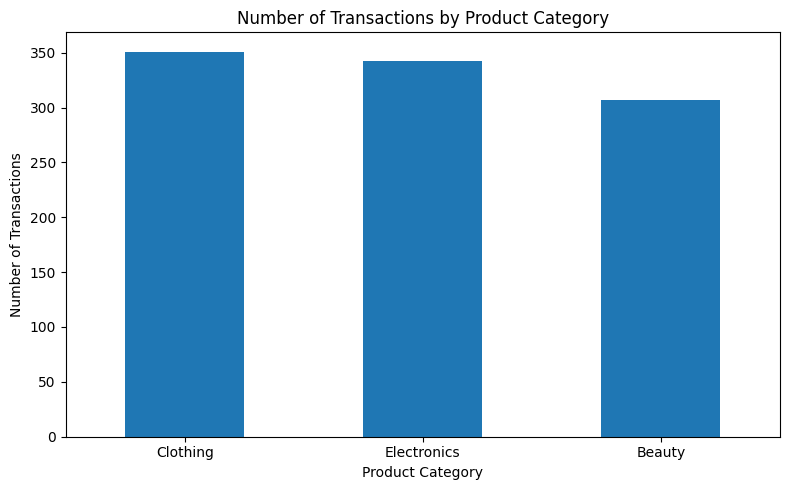

In [ ]:
# Count transactions by product category

category_count = df["Product Category"].value_counts()

print("----- TRANSACTIONS BY CATEGORY -----")
print(category_count)

# Create bar chart
plt.figure(figsize=(8, 5))

category_count.plot(kind="bar")

plt.title("Number of Transactions by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

----- AVERAGE SALES BY CATEGORY -----
Product Category
Beauty         467.475570
Clothing       443.247863
Electronics    458.786550
Name: Total Amount, dtype: float64


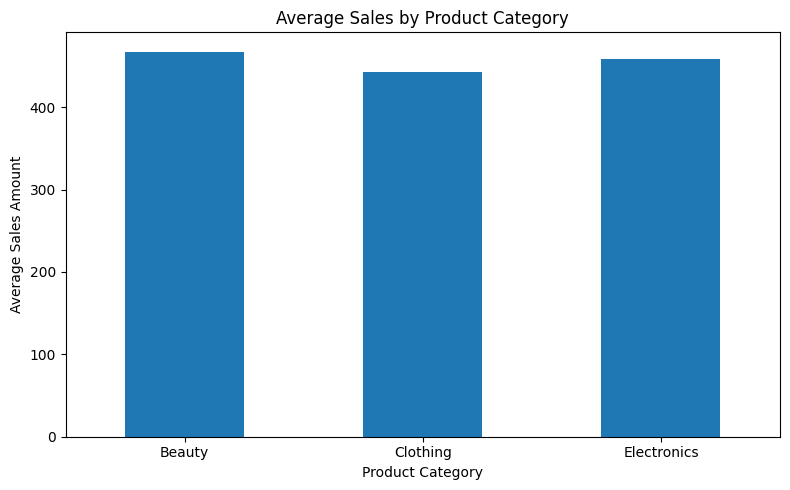

In [ ]:
# Average Sales by Product Category

average_sales = df.groupby("Product Category")["Total Amount"].mean()

print("----- AVERAGE SALES BY CATEGORY -----")
print(average_sales)

# Bar Chart
plt.figure(figsize=(8, 5))

average_sales.plot(kind="bar")

plt.title("Average Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Sales Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Conclusion

The exploratory data analysis helped me understand the main patterns in the retail sales dataset.

- The 46–55 age group generated the highest sales among the analysed age groups.
- May 2023 recorded the highest monthly sales in the dataset.
- Price per Unit and Total Amount showed a strong positive relationship.

### Business Recommendations

1. The business can focus more marketing efforts on the 46–55 customer group because it generated the highest sales.
2. The business can analyse high-sales months and plan promotions or inventory accordingly during similar periods.
3. The business can use product pricing and quantity information together to understand factors that contribute to higher total sales.

Overall, this project helped me understand how exploratory data analysis can be used to identify sales patterns and generate useful business insights.